### Second test with `pykan` package: Train KAN model on Higgs Boson dataset

In [1]:
import torch
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
df = pd.read_parquet("../data/processed/higgs-challenge.parquet")
df

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_pt_h,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,DER_pt_ratio_lep_tau,DER_met_phi_centrality,PRI_tau_pt,PRI_tau_eta,PRI_tau_phi,PRI_lep_pt,PRI_lep_eta,PRI_lep_phi,PRI_met,PRI_met_phi,PRI_jet_num,Weight,Label
0,0.291563,0.312518,-0.537513,0.827433,1.051324,0.250474,0.177739,1.125455,-0.306146,0.852137,0.219323,0.195481,1.831549,-1.356914,-0.664722,-0.151299,0.946720,0.000814,0
1,0.686119,0.867758,-0.229628,1.362732,-0.806740,-0.357485,-0.640228,1.140558,0.103214,1.699803,-1.647922,-0.459562,0.412759,0.030247,0.201519,-1.055246,-0.073277,0.681042,1
2,0.387010,1.278162,-0.958379,1.149398,-0.884327,-0.769381,1.075991,-1.124062,-0.742357,-1.364071,0.015093,0.270970,-0.406328,-1.734980,-0.221721,0.034564,-1.093274,1.660654,1
3,0.948261,-0.814641,-0.714235,1.909810,-0.138723,-0.919983,-0.434281,-1.207968,-0.499518,-1.813616,-1.218544,-0.777730,0.650558,0.838185,-1.102844,-0.478904,-1.093274,1.904263,1
4,-0.564143,-0.923820,0.811589,-1.400143,1.969445,0.929718,-0.978817,0.356038,0.611290,0.316332,0.741182,-0.697966,-0.696172,0.996906,0.078201,1.235231,1.966717,0.025434,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693631,-0.284492,0.143411,1.419955,-1.508773,-0.617670,0.745303,-0.896206,1.080985,0.974501,1.728833,1.041196,-0.285469,1.691431,-1.752065,1.077329,1.255086,0.946720,0.005721,0
693632,-0.396430,-0.386943,0.040837,-0.180342,-0.768926,0.676044,-0.000282,1.127133,-0.477600,-1.421301,0.048122,-0.277096,-1.247834,1.273567,-0.101852,0.851371,0.946720,0.000461,0
693633,-0.234811,-1.044290,-0.689792,0.406000,-0.064074,-0.835291,-0.915986,-0.747325,0.079812,0.885313,0.573835,-0.918243,0.881952,-0.972786,-0.240953,-1.136872,-1.093274,1.189365,1
693634,-0.441792,-0.714351,-0.510322,0.061786,-0.775920,-0.554109,-0.573906,1.137202,-0.134255,-1.027327,-0.838159,-0.578920,-0.961994,0.490981,-0.980924,-0.280356,-0.073277,0.512740,1


For this test, instead of doing as the proposal says and using Cross Validation on the entire dataset, because we are just testing the package, we will do a simple train/test split.

In [4]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Label"])

print(f"Train set size: {len(train_df)}, Test set size: {len(test_df)}")

y_train = train_df["Label"].values
w_train = train_df["Weight"].values
X_test = test_df.drop(columns=["Label", "Weight"]).values
y_test = test_df["Label"].values
w_test = test_df["Weight"].values

dataset = {
    # Encoding label as float, but we'll use binary cross-entropy loss regardless
    "train_input": torch.tensor(train_df.drop(columns=["Label", "Weight"]).values, dtype=torch.float32).to(device),
    "train_label": torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32).to(device),
    "train_weight": torch.tensor(w_train.reshape(-1, 1), dtype=torch.float32).to(device),
    "test_input": torch.tensor(X_test, dtype=torch.float32).to(device),
    "test_label": torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32).to(device),
    "test_weight": torch.tensor(w_test.reshape(-1, 1), dtype=torch.float32).to(device),
}

Train set size: 554908, Test set size: 138728


In [5]:
num_features = dataset["train_input"].shape[1]
print(f"Number of features: {num_features}")

Number of features: 17


### Using KAN

In [6]:
from kan import KAN


class KANClassifier(KAN):
    def forward(self, x, *args, **kwargs):
        out = super().forward(x, *args, **kwargs)
        return torch.sigmoid(out)

In [7]:
from src.checkpoints import add_gitignore
from torch import nn


def test_acc():
    return torch.mean(((model_kan(dataset["test_input"]) >= 0.5).int() == dataset["test_label"]).float()).float()


def train_acc():
    train_sample = 1000  # Otherwise this would take too long, in each training step, plus we would have memory issues
    preds = (model_kan(dataset["train_input"][:train_sample]) >= 0.5).int()
    return torch.mean((preds == dataset["train_label"][:train_sample]).float()).float()


loss_fn = nn.BCELoss()

ckpt_path = "../models/pykan-higgs-test/"
add_gitignore(ckpt_path)
model_kan = KANClassifier(width=[num_features, 100, 1], grid=3, k=3, seed=42, ckpt_path=ckpt_path).to(device)
# Important note: Because the KAN is supposed to learn the probability directly, we are hoping that the KAN is capable
# of learning a sigmoid-like function in its last layer. Therefore, we do not apply a sigmoid activation at the end of
# the KAN model.
batch_size = 32768
epochs = 20
history = model_kan.fit(
    dataset,
    opt="Adam",
    lr=0.001,
    steps=epochs * len(dataset["train_input"]) // batch_size,  # The trainer samples randomly each iteration, so this
    # param doesn't control epochs directly. But if we want to train this network for roughly the same amount of
    # iterations as the MLP below (10 epochs), we can set it like this. Note that THIS DOES NOT MEAN THAT THE MODEL WILL
    # SEE ALL SAMPLES 10 TIMES, as would be the case in normal epoch-based training.
    lamb=0.001,
    lamb_entropy=5.0,
    update_grid=False,
    loss_fn=loss_fn,
    batch=batch_size,  # Using mini-batches for training (number chosen to fit in GPU memory)
    metrics=(test_acc, train_acc),
)

checkpoint directory created: ../models/pykan-higgs-test/
saving model version 0.0


| train_loss: 6.66e-01 | test_loss: 6.64e-01 | reg: 6.61e+01 | : 100%|█| 338/338 [02:34<00:00,  2.19

saving model version 0.1


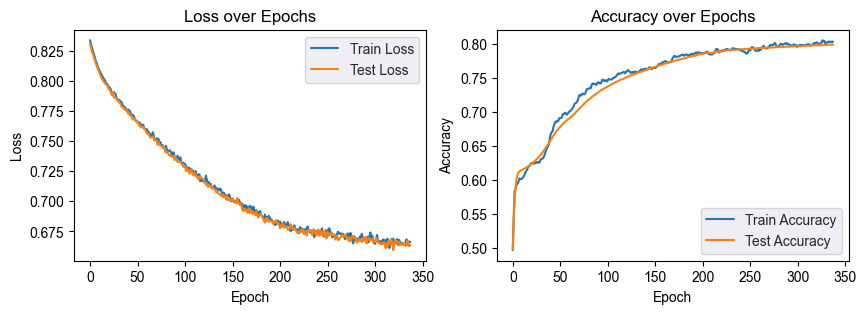

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting training history
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
sns.set_style("darkgrid")

ax[0].plot(history["train_loss"], label="Train Loss")
ax[0].plot(history["test_loss"], label="Test Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("Loss over Epochs")
ax[0].legend()

ax[1].plot(history["train_acc"], label="Train Accuracy")
ax[1].plot(history["test_acc"], label="Test Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Accuracy over Epochs")
ax[1].legend()


plt.show()

In [9]:
from src.evaluate import report_metrics


def evaluate_model(model, dataset):
    model.eval()
    with torch.no_grad():
        test_proba = model(dataset["test_input"]).cpu().numpy()
        test_preds = (test_proba >= 0.5).astype(int)
    test_labels = dataset["test_label"].cpu().numpy()
    test_weights = dataset["test_weight"].cpu().numpy()

    report_metrics(y_true=test_labels, y_pred=test_preds, y_proba=test_proba, weights=test_weights)


evaluate_model(model_kan, dataset)

Accuracy: 0.7993916152471022
Classification report:
               precision    recall  f1-score   support

  background       0.76      0.71      0.73     54075
      signal       0.82      0.86      0.84     84653

    accuracy                           0.80    138728
   macro avg       0.79      0.78      0.79    138728
weighted avg       0.80      0.80      0.80    138728

ROC AUC: 0.8690256505468992
AMS: 782.7232666015625


### Now let's repeat the experiment using an MLP

In [10]:
from sklearn.neural_network import MLPClassifier

model_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    random_state=42,
    max_iter=20,  # Number of epochs
)
model_mlp.fit(
    dataset["train_input"].cpu().numpy(),
    dataset["train_label"].cpu().numpy().ravel(),
)

c:\Users\mirxm\Storage\Work\MDS\S3\AML\HiggsBosonKAN\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",20
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [11]:
test_proba = model_mlp.predict_proba(dataset["test_input"].cpu().numpy())[:, 1].reshape(-1, 1)
test_preds = (test_proba >= 0.5).astype(int)
test_labels = dataset["test_label"].cpu().numpy()
test_weights = dataset["test_weight"].cpu().numpy()


report_metrics(y_true=test_labels, y_pred=test_preds, y_proba=test_proba, weights=test_weights)

Accuracy: 0.8135271898967764
Classification report:
               precision    recall  f1-score   support

  background       0.77      0.74      0.75     54075
      signal       0.84      0.86      0.85     84653

    accuracy                           0.81    138728
   macro avg       0.81      0.80      0.80    138728
weighted avg       0.81      0.81      0.81    138728

ROC AUC: 0.8899980467431486
AMS: 790.4531860351562
